In [ ]:
# ── Cell 1: Install dependencies ──────────────────────────────────────────────
!pip install librosa scikit-learn matplotlib seaborn tensorflow --quiet
!pip install kaggle --quiet

In [ ]:
# ── Cell 2: Mount Drive & Download RAVDESS ────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os, zipfile

# ── Paths ─────────────────────────────────────────────────────────────────────
ZIP_PATH    = '/content/drive/MyDrive/DL_Case/ravdess.zip'  # your zip in Drive
EXTRACT_DIR = '/content/ravdess'                             # extract here (local, faster)

# ── Extract only if not already done ──────────────────────────────────────────
if not os.path.exists(EXTRACT_DIR):
    print("Extracting dataset... (this takes ~1-2 min)")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall(EXTRACT_DIR)
    print("Extraction complete.")
else:
    print("Already extracted, skipping.")

# ── Verify ────────────────────────────────────────────────────────────────────
wav_files = []
for root, dirs, files in os.walk(EXTRACT_DIR):
    for f in files:
        if f.endswith('.wav'):
            wav_files.append(os.path.join(root, f))

print(f"Total .wav files found: {len(wav_files)}")
print(f"Sample path: {wav_files[0] if wav_files else 'NONE — check zip structure'}")

DATASET_PATH = EXTRACT_DIR

Mounted at /content/drive
Extracting dataset... (this takes ~1-2 min)
Extraction complete.
Total .wav files found: 2880
Sample path: /content/ravdess/Actor_07/03-01-04-02-01-01-07.wav


In [ ]:
import numpy as np
import pandas as pd
import librosa
import os, glob, re
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, Model, callbacks

tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# RAVDESS filename format: 03-01-05-01-01-01-12.wav
# Position 3 (index 2) = emotion code

STRESS_EMOTIONS = {5, 6, 7}      # angry, fearful, disgust → stress
NONSTRESS_EMOTIONS = {1, 2, 3, 4} # neutral, calm, happy, sad → non-stress

def parse_ravdess_label(filepath):
    fname = os.path.basename(filepath)
    parts = fname.replace('.wav','').split('-')
    emotion_code = int(parts[2])
    if emotion_code in STRESS_EMOTIONS:
        return 1
    elif emotion_code in NONSTRESS_EMOTIONS:
        return 0
    return None  # skip 'surprised' (08) for cleaner binary

# For TESS: filenames like OAF_angry_word.wav
TESS_STRESS = {'angry', 'disgust', 'fear'}

def parse_tess_label(filepath):
    fname = os.path.basename(filepath).lower()
    for emotion in TESS_STRESS:
        if emotion in fname:
            return 1
    return 0

In [ ]:
def extract_features(filepath, sr=22050, max_pad_len=174, n_mfcc=40):
    """
    Extracts:
      - MFCC (40 coefficients)
      - Delta MFCC (velocity)
      - Delta-Delta MFCC (acceleration)
      - Zero Crossing Rate
      - RMS Energy
    Returns shape: (max_pad_len, n_features)
    """
    try:
        y, sr = librosa.load(filepath, sr=sr, mono=True)

        # Trim leading/trailing silence
        y, _ = librosa.effects.trim(y, top_db=20)

        # ── MFCC + derivatives ────────────────────────────────────────────────
        mfcc        = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)   # (40, T)
        mfcc_delta  = librosa.feature.delta(mfcc)                         # (40, T)
        mfcc_delta2 = librosa.feature.delta(mfcc, order=2)                # (40, T)

        # ── Prosodic features ─────────────────────────────────────────────────
        zcr = librosa.feature.zero_crossing_rate(y)                       # (1, T)
        rms = librosa.feature.rms(y=y)                                    # (1, T)

        # Stack all → (82, T)
        features = np.vstack([mfcc, mfcc_delta, mfcc_delta2, zcr, rms])

        # ── Pad / truncate to fixed length ────────────────────────────────────
        if features.shape[1] < max_pad_len:
            pad_width = max_pad_len - features.shape[1]
            features = np.pad(features, ((0,0),(0,pad_width)), mode='constant')
        else:
            features = features[:, :max_pad_len]

        # Transpose → (T=174, 82) — LSTM expects (timesteps, features)
        return features.T

    except Exception as e:
        print(f"Error processing {filepath}: {e}")
        return None

# Test on one file
sample_files = glob.glob(os.path.join(DATASET_PATH, '**/*.wav'), recursive=True)
print(f"Total files found: {len(sample_files)}")

if len(sample_files) > 0:
    feat = extract_features(sample_files[0])
    print(f"Feature shape: {feat.shape}")  # should be (174, 82)

Total files found: 2880
Feature shape: (174, 122)


In [ ]:
# ── Cell 6: Build full dataset ────────────────────────────────────────────────
def build_dataset(dataset_path, dataset_type='ravdess'):
    X, y = [], []
    files = glob.glob(os.path.join(dataset_path, '**/*.wav'), recursive=True)

    print(f"Processing {len(files)} files...")

    for fp in files:
        if dataset_type == 'ravdess':
            label = parse_ravdess_label(fp)
        else:
            label = parse_tess_label(fp)

        if label is None:
            continue

        features = extract_features(fp)
        if features is not None:
            X.append(features)
            y.append(label)

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)

    print(f"Dataset shape: X={X.shape}, y={y.shape}")
    print(f"Stress samples: {y.sum():.0f} | Non-stress: {(1-y).sum():.0f}")
    print(f"Class balance: {y.mean()*100:.1f}% stress")
    return X, y

X, y = build_dataset(DATASET_PATH, dataset_type='ravdess')

Processing 2880 files...
Dataset shape: X=(2496, 174, 122), y=(2496,)
Stress samples: 1152 | Non-stress: 1344
Class balance: 46.2% stress


In [ ]:
# ── Cell 7: Normalize and split ───────────────────────────────────────────────
# Reshape for scaling: (N, T, F) → (N*T, F)
N, T, F = X.shape
X_reshaped = X.reshape(-1, F)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reshaped).reshape(N, T, F)

# Save scaler for inference
import joblib
joblib.dump(scaler, '/content/drive/MyDrive/stress_scaler.pkl')

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.15,
    stratify=y_train,
    random_state=42
)

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

Train: (1696, 174, 122) | Val: (300, 174, 122) | Test: (500, 174, 122)


In [ ]:

# ── Cell 8: Custom Attention Layer ────────────────────────────────────────────
class AttentionLayer(layers.Layer):
    """
    Bahdanau-style soft attention.
    Input:  (batch, timesteps, hidden_dim)
    Output: (batch, hidden_dim)  — context vector
            (batch, timesteps)   — attention weights (for visualization)
    """
    def __init__(self, units=64, **kwargs):
        super().__init__(**kwargs)
        self.W = layers.Dense(units, use_bias=False)
        self.V = layers.Dense(1, use_bias=False)

    def call(self, hidden_states):
        # hidden_states: (batch, T, H)
        score = self.V(tf.nn.tanh(self.W(hidden_states)))  # (batch, T, 1)
        weights = tf.nn.softmax(score, axis=1)              # (batch, T, 1)
        context = tf.reduce_sum(weights * hidden_states, axis=1)  # (batch, H)
        return context, tf.squeeze(weights, axis=-1)        # (batch, T)

    def get_config(self):
        config = super().get_config()
        return config

In [ ]:
# ── Cell 9: Build full model ───────────────────────────────────────────────────
def build_attention_bilstm(input_shape, lstm_units=128, dense_units=64,
                            attention_units=64, dropout_rate=0.4):
    inputs = layers.Input(shape=input_shape, name='speech_input')

    # ── First BiLSTM ──────────────────────────────────────────────────────────
    x = layers.Bidirectional(
        layers.LSTM(lstm_units, return_sequences=True,
                    recurrent_dropout=0.1, name='lstm_1'),
        name='bilstm_1'
    )(inputs)
    x = layers.Dropout(0.3, name='dropout_1')(x)

    # ── Second BiLSTM ─────────────────────────────────────────────────────────
    x = layers.Bidirectional(
        layers.LSTM(lstm_units // 2, return_sequences=True,
                    recurrent_dropout=0.1, name='lstm_2'),
        name='bilstm_2'
    )(x)
    x = layers.Dropout(0.2, name='dropout_2')(x)

    # ── Attention ─────────────────────────────────────────────────────────────
    attention = AttentionLayer(units=attention_units, name='attention')
    context, attn_weights = attention(x)

    # ── Classification head ───────────────────────────────────────────────────
    x = layers.Dense(dense_units, activation='relu', name='dense_1')(context)
    x = layers.BatchNormalization(name='bn_1')(x)
    x = layers.Dropout(dropout_rate, name='dropout_3')(x)

    outputs = layers.Dense(1, activation='sigmoid', name='output')(x)

    model      = Model(inputs, outputs,      name='AttentionBiLSTM')
    attn_model = Model(inputs, attn_weights, name='AttentionExtractor')

    return model, attn_model

INPUT_SHAPE = (X_train.shape[1], X_train.shape[2])
model, attn_model = build_attention_bilstm(INPUT_SHAPE)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

model.summary()

Model: "AttentionBiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ speech_input (InputLayer)       │ (None, 174, 122)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ (None, 174, 256)       │       257,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 174, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ (None, 174, 128)       │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 174, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (AttentionLayer)      │ [(None, 128), (None,   │         8,256 │
│                                 │ 174)]                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 438,209 (1.67 MB)

 Trainable params: 438,081 (1.67 MB)

 Non-trainable params: 128 (512.00 B)

Training

In [ ]:
# ── Cell 10: Callbacks ────────────────────────────────────────────────────────
SAVE_PATH = '/content/drive/MyDrive/stress_model.h5'

cb_list = [
    callbacks.ModelCheckpoint(
        SAVE_PATH, monitor='val_auc', mode='max',
        save_best_only=True, verbose=1
    ),
    callbacks.EarlyStopping(
        monitor='val_auc', patience=12, restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5,
        min_lr=1e-6, verbose=1
    ),
    callbacks.CSVLogger('/content/training_log.csv')
]

In [ ]:
from tensorflow.keras import regularizers
from sklearn.utils import class_weight

def build_attention_bilstm_v2(input_shape, lstm_units=96, dense_units=48,
                               attention_units=64, dropout_rate=0.5):
    inputs = layers.Input(shape=input_shape, name='speech_input')

    x = layers.Bidirectional(
        layers.LSTM(lstm_units, return_sequences=True,
                    recurrent_dropout=0.3,
                    kernel_regularizer=regularizers.l2(1e-4),
                    name='lstm_1'),
        name='bilstm_1'
    )(inputs)
    x = layers.Dropout(0.4, name='dropout_1')(x)

    x = layers.Bidirectional(
        layers.LSTM(lstm_units // 2, return_sequences=True,
                    recurrent_dropout=0.3,
                    kernel_regularizer=regularizers.l2(1e-4),
                    name='lstm_2'),
        name='bilstm_2'
    )(x)
    x = layers.Dropout(0.3, name='dropout_2')(x)

    attention = AttentionLayer(units=attention_units, name='attention')
    context, attn_weights = attention(x)

    x = layers.Dense(dense_units, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4),
                     name='dense_1')(context)
    x = layers.BatchNormalization(name='bn_1')(x)
    x = layers.Dropout(dropout_rate, name='dropout_3')(x)

    outputs = layers.Dense(1, activation='sigmoid', name='output')(x)

    model      = Model(inputs, outputs,      name='AttentionBiLSTM_v2')
    attn_model = Model(inputs, attn_weights, name='AttentionExtractor_v2')
    return model, attn_model


model, attn_model = build_attention_bilstm_v2(INPUT_SHAPE)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

# ── Mixup generator with sample weights baked in ──────────────────────────────
def mixup_generator(X, y, class_weight_dict, batch_size=32, alpha=0.3):
    """
    Yields (X_batch, y_batch, sample_weights) so Keras uses
    per-sample weighting instead of class_weight argument.
    """
    n = len(X)
    # Pre-compute per-sample weights from class_weight_dict
    sample_weights = np.array([class_weight_dict[int(label)] for label in y],
                               dtype=np.float32)
    while True:
        idx1 = np.random.permutation(n)
        idx2 = np.random.permutation(n)
        for start in range(0, n, batch_size):
            i1 = idx1[start:start + batch_size]
            i2 = idx2[start:start + batch_size]

            lam = np.random.beta(alpha, alpha,
                                 size=(len(i1), 1, 1)).astype(np.float32)

            X_mix = lam * X[i1] + (1 - lam) * X[i2]
            y_mix = lam[:, 0, 0] * y[i1] + (1 - lam[:, 0, 0]) * y[i2]

            # Blend sample weights the same way
            w_mix = lam[:, 0, 0] * sample_weights[i1] + \
                    (1 - lam[:, 0, 0]) * sample_weights[i2]

            yield X_mix, y_mix, w_mix


# ── Callbacks ─────────────────────────────────────────────────────────────────
SAVE_PATH = '/content/drive/MyDrive/stress_model_v2.keras'

cb_list = [
    callbacks.ModelCheckpoint(
        SAVE_PATH, monitor='val_auc', mode='max',
        save_best_only=True, verbose=1
    ),
    callbacks.EarlyStopping(
        monitor='val_auc', patience=10,
        restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.4, patience=6,
        min_lr=1e-6, verbose=1
    ),
    callbacks.CSVLogger('/content/training_log_v2.csv')
]

# Calculate class weights for imbalanced datasets
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
cw_dict = {i: class_weights[i] for i in range(len(class_weights))}

# ── Train ─────────────────────────────────────────────────────────────────────
BATCH_SIZE       = 32
STEPS_PER_EPOCH  = len(X_train) // BATCH_SIZE

history = model.fit(
    mixup_generator(X_train, y_train, cw_dict,
                    batch_size=BATCH_SIZE,
                    alpha=0.1),
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_data=(X_val, y_val),
    epochs=50,
    callbacks=cb_list,
    verbose=1
)

Epoch 1/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3372 - auc: 0.5620 - loss: 0.8538 - precision: 0.7454 - recall: 0.5490
Epoch 1: val_auc improved from None to 0.81157, saving model to /content/drive/MyDrive/stress_model_v2.keras

Epoch 1: finished saving model to /content/drive/MyDrive/stress_model_v2.keras
53/53 ━━━━━━━━━━━━━━━━━━━━ 120s 2s/step - accuracy: 0.3667 - auc: 0.6113 - loss: 0.7906 - precision: 0.7669 - recall: 0.5557 - val_accuracy: 0.7300 - val_auc: 0.8116 - val_loss: 0.7461 - val_precision: 0.7714 - val_recall: 0.5870 - learning_rate: 3.0000e-04
Epoch 2/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4093 - auc: 0.7107 - loss: 0.6671 - precision: 0.8469 - recall: 0.6045
Epoch 2: val_auc improved from 0.81157 to 0.89685, saving model to /content/drive/MyDrive/stress_model_v2.keras

Epoch 2: finished saving model to /content/drive/MyDrive/stress_model_v2.keras
53/53 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step - accuracy: 0.4239 - auc: 0.7361 - loss: 0.6297 - pre

# BASELINE COMPARISION

In [ ]:
# ── Cell: Baseline Comparison ─────────────────────────────────────────────────
# Purpose:
# Compare simple baseline models against the proposed Attention-BiLSTM model.
# This helps prove that the case study is more than a basic CNN/pretrained-model project.

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
import time

# Keep baseline training lighter than the final model.
BASELINE_EPOCHS = 15
BASELINE_BATCH_SIZE = 32

def compile_binary_model(model, learning_rate=3e-4):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.AUC(name='auc')
        ]
    )
    return model


def build_mlp_baseline(input_shape):
    """
    Baseline 1: MLP
    Flattens the full time-feature matrix and uses dense layers.
    This is a weak baseline because it does not explicitly model speech sequence order.
    """
    inputs = layers.Input(shape=input_shape, name='speech_input')
    x = layers.Flatten(name='flatten')(inputs)
    x = layers.Dense(128, activation='relu', name='dense_1')(x)
    x = layers.BatchNormalization(name='bn_1')(x)
    x = layers.Dropout(0.4, name='dropout_1')(x)
    x = layers.Dense(64, activation='relu', name='dense_2')(x)
    x = layers.Dropout(0.3, name='dropout_2')(x)
    outputs = layers.Dense(1, activation='sigmoid', name='output')(x)
    return Model(inputs, outputs, name='MLP_Baseline')


def build_cnn1d_baseline(input_shape):
    """
    Baseline 2: 1D CNN
    Learns local temporal patterns from speech feature frames.
    This is stronger than MLP but may not capture long-range sequence dependencies well.
    """
    inputs = layers.Input(shape=input_shape, name='speech_input')
    x = layers.Conv1D(64, kernel_size=5, padding='same', activation='relu', name='conv1')(inputs)
    x = layers.BatchNormalization(name='bn_1')(x)
    x = layers.MaxPooling1D(pool_size=2, name='pool_1')(x)
    x = layers.Dropout(0.3, name='dropout_1')(x)

    x = layers.Conv1D(128, kernel_size=3, padding='same', activation='relu', name='conv2')(x)
    x = layers.BatchNormalization(name='bn_2')(x)
    x = layers.GlobalAveragePooling1D(name='gap')(x)

    x = layers.Dense(64, activation='relu', name='dense_1')(x)
    x = layers.Dropout(0.4, name='dropout_2')(x)
    outputs = layers.Dense(1, activation='sigmoid', name='output')(x)
    return Model(inputs, outputs, name='CNN1D_Baseline')


def build_bilstm_baseline(input_shape):
    """
    Baseline 3: BiLSTM without Attention
    Models sequential speech patterns, but does not include attention interpretability.
    """
    inputs = layers.Input(shape=input_shape, name='speech_input')
    x = layers.Bidirectional(
        layers.LSTM(96, return_sequences=True, recurrent_dropout=0.2),
        name='bilstm_1'
    )(inputs)
    x = layers.Dropout(0.3, name='dropout_1')(x)

    x = layers.Bidirectional(
        layers.LSTM(48, return_sequences=False, recurrent_dropout=0.2),
        name='bilstm_2'
    )(x)
    x = layers.Dropout(0.4, name='dropout_2')(x)

    x = layers.Dense(48, activation='relu', name='dense_1')(x)
    outputs = layers.Dense(1, activation='sigmoid', name='output')(x)
    return Model(inputs, outputs, name='BiLSTM_Baseline')


def evaluate_binary_model(model_to_eval, model_name, X_test, y_test):
    """
    Returns important metrics for the comparison table.
    """
    y_prob = model_to_eval.predict(X_test, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)

    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'Parameters': model_to_eval.count_params()
    }


def train_baseline_model(model_builder, model_name):
    """
    Trains one baseline model and returns the trained model plus evaluation metrics.
    """
    print("\n" + "=" * 70)
    print(f"Training: {model_name}")
    print("=" * 70)

    baseline_model = model_builder(INPUT_SHAPE)
    compile_binary_model(baseline_model)

    baseline_callbacks = [
        callbacks.EarlyStopping(
            monitor='val_auc',
            patience=4,
            mode='max',
            restore_best_weights=True,
            verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=1
        )
    ]

    start = time.time()
    history_baseline = baseline_model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=BASELINE_EPOCHS,
        batch_size=BASELINE_BATCH_SIZE,
        class_weight=cw_dict,   # uses the class weights calculated earlier
        callbacks=baseline_callbacks,
        verbose=1
    )
    training_time = time.time() - start

    result = evaluate_binary_model(baseline_model, model_name, X_test, y_test)
    result['Training Time (sec)'] = round(training_time, 2)

    return baseline_model, history_baseline, result


# Train baseline models
baseline_results = []
trained_baselines = {}

for builder, name in [
    (build_mlp_baseline, 'MLP Baseline'),
    (build_cnn1d_baseline, '1D CNN Baseline'),
    (build_bilstm_baseline, 'BiLSTM Baseline')
]:
    trained_model, trained_history, result = train_baseline_model(builder, name)
    trained_baselines[name] = trained_model
    baseline_results.append(result)


# Evaluate your already-trained proposed model
proposed_result = evaluate_binary_model(
    model,
    'Proposed Attention-BiLSTM',
    X_test,
    y_test
)
proposed_result['Training Time (sec)'] = 'Already trained'
baseline_results.append(proposed_result)


# Create final comparison table
comparison_df = pd.DataFrame(baseline_results)

# Sort by F1-score first, then ROC-AUC
comparison_df = comparison_df.sort_values(
    by=['F1-Score', 'ROC-AUC'],
    ascending=False
).reset_index(drop=True)

print("\nFinal Baseline Comparison Table:")
display(comparison_df)

# Save for report
comparison_df.to_csv('/content/baseline_comparison_results.csv', index=False)
print("\nSaved comparison table to: /content/baseline_comparison_results.csv")



Training: MLP Baseline
Epoch 1/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.6657 - auc: 0.7249 - loss: 0.6945 - precision: 0.6561 - recall: 0.5798 - val_accuracy: 0.8300 - val_auc: 0.9024 - val_loss: 0.3936 - val_precision: 0.8175 - val_recall: 0.8116 - learning_rate: 3.0000e-04
Epoch 2/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8373 - auc: 0.9215 - loss: 0.3595 - precision: 0.8322 - recall: 0.8110 - val_accuracy: 0.9033 - val_auc: 0.9623 - val_loss: 0.2607 - val_precision: 0.9225 - val_recall: 0.8623 - learning_rate: 3.0000e-04
Epoch 3/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9216 - auc: 0.9800 - loss: 0.2086 - precision: 0.9232 - recall: 0.9055 - val_accuracy: 0.9300 - val_auc: 0.9827 - val_loss: 0.1899 - val_precision: 0.9466 - val_recall: 0.8986 - learning_rate: 3.0000e-04
Epoch 4/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9522 - auc: 0.9920 - loss: 0.1445 - precision: 0.9377 - recall: 0.9604 - val_accuracy: 0.9500 - val_auc: 0.

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Parameters,Training Time (sec)
0,Proposed Attention-BiLSTM,0.972,0.961702,0.978355,0.969957,0.997860,271841,Already trained
1,1D CNN Baseline,0.946,0.932203,0.952381,0.942184,0.975893,72897,15.86
2,BiLSTM Baseline,0.946,0.939655,0.943723,0.941685,0.985838,265441,774.85
3,MLP Baseline,0.944,0.955157,0.922078,0.938326,0.983022,2726145,12.4



Saved comparison table to: /content/baseline_comparison_results.csv


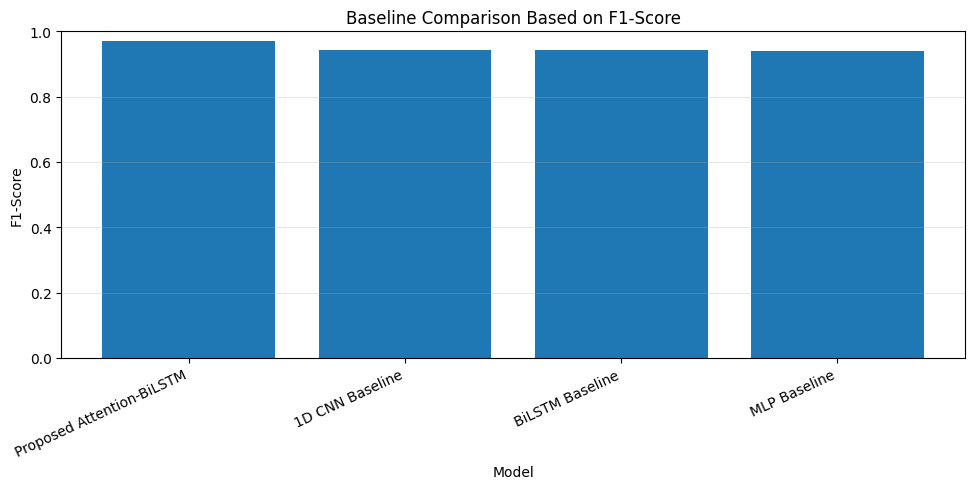

In [ ]:
# ── Cell: Baseline Comparison Plot ────────────────────────────────────────────
# This chart can be added directly to the case study report.

plt.figure(figsize=(10, 5))
plt.bar(comparison_df['Model'], comparison_df['F1-Score'])
plt.title('Baseline Comparison Based on F1-Score')
plt.xlabel('Model')
plt.ylabel('F1-Score')
plt.xticks(rotation=25, ha='right')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/baseline_comparison_f1.png', dpi=150)
plt.show()


## Baseline Comparison

The project was evaluated against multiple baseline models. First, an MLP baseline was used to test whether flattened acoustic features alone were sufficient for stress detection. Next, a 1D CNN baseline was implemented to capture local temporal patterns in speech frames. A BiLSTM baseline was then tested to model sequential dependencies in both forward and backward directions. Finally, the proposed Attention-BiLSTM model was evaluated. The proposed model is stronger because it not only captures temporal speech patterns but also uses an attention mechanism to highlight important speech frames, improving interpretability. Therefore, the final architecture was selected based on experimental comparison rather than simple model application.


Evaluation & Visualization

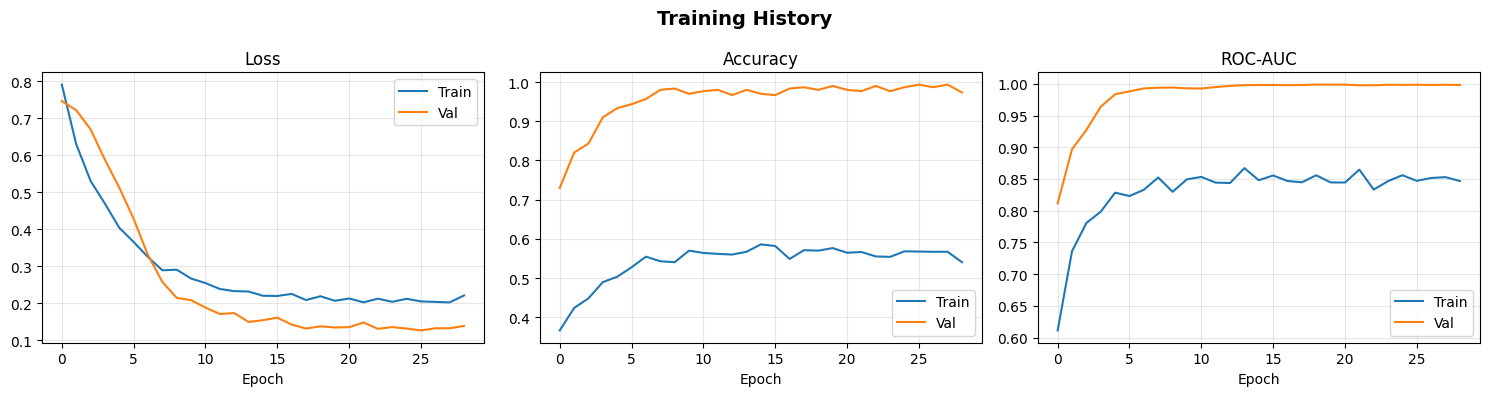

In [ ]:
# ── Cell 12: Training curves ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Training History', fontsize=14, fontweight='bold')

for ax, metric, title in zip(axes,
        ['loss', 'accuracy', 'auc'],
        ['Loss', 'Accuracy', 'ROC-AUC']):
    ax.plot(history.history[metric], label='Train')
    ax.plot(history.history[f'val_{metric}'], label='Val')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150)
plt.show()

In [ ]:
# ── Cell 13: Test evaluation ───────────────────────────────────────────────────
y_prob = model.predict(X_test, verbose=0).flatten()
y_pred = (y_prob >= 0.5).astype(int)

print("=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_test, y_pred,
      target_names=['Non-Stress', 'Stress']))

roc_auc = roc_auc_score(y_test, y_prob)
print(f"\nROC-AUC Score: {roc_auc:.4f}")

CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Non-Stress       0.98      0.97      0.97       269
      Stress       0.96      0.98      0.97       231

    accuracy                           0.97       500
   macro avg       0.97      0.97      0.97       500
weighted avg       0.97      0.97      0.97       500


ROC-AUC Score: 0.9979


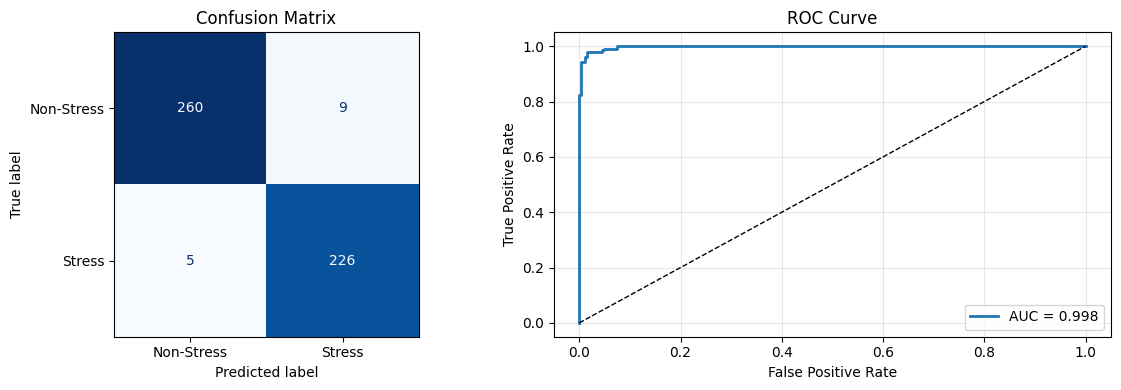

In [ ]:
# ── Cell 14: Confusion matrix ─────────────────────────────────────────────────
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Non-Stress','Stress']).plot(
    ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title('Confusion Matrix')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/evaluation.png', dpi=150)
plt.show()

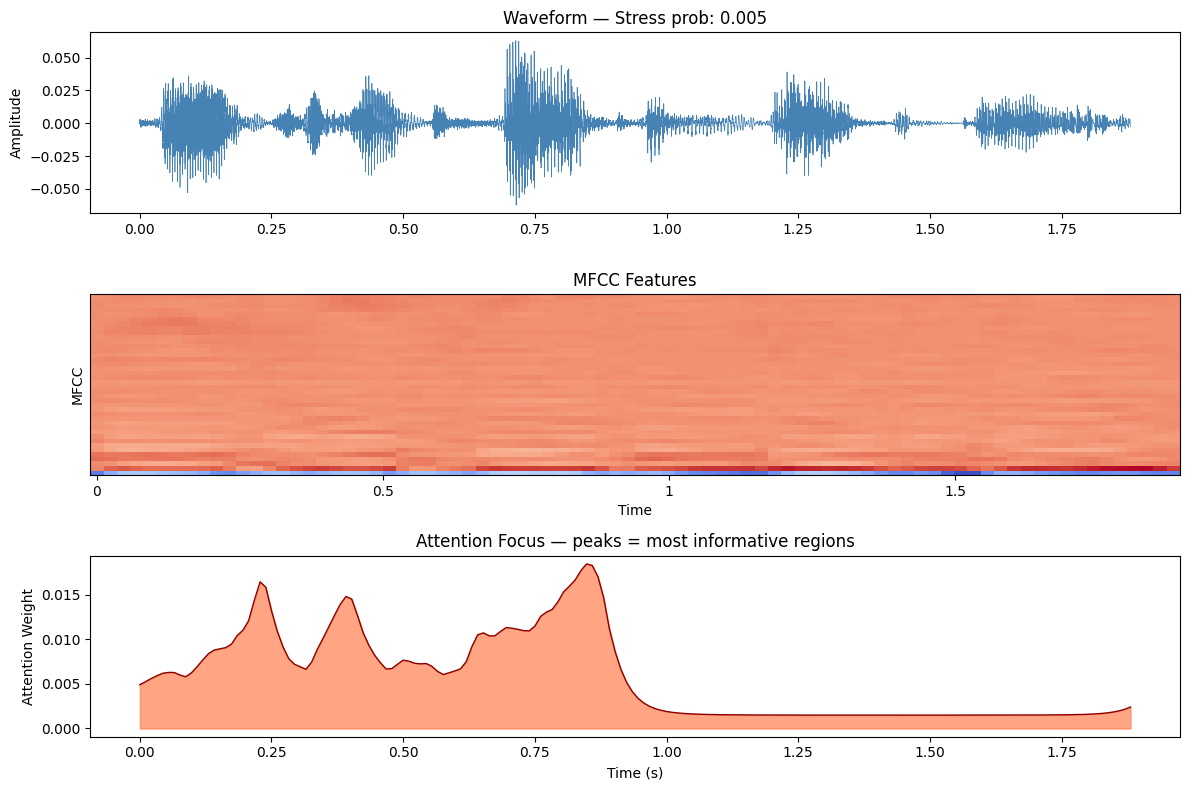


Prediction: NON-STRESS (confidence: 0.5%)


In [ ]:
# ── Cell 15: Attention visualization (the "interpretability" section) ──────────
def visualize_attention(audio_path, model, attn_model, scaler,
                         n_mfcc=40, max_pad_len=174):
    """
    Shows which time frames the model focuses on — great for the report.
    """
    y_audio, sr = librosa.load(audio_path, sr=22050, mono=True)
    y_audio, _ = librosa.effects.trim(y_audio, top_db=20)

    feat = extract_features(audio_path)
    feat_scaled = scaler.transform(feat.reshape(-1, feat.shape[-1])).reshape(1, *feat.shape)

    # Get predictions
    prob = model.predict(feat_scaled, verbose=0)[0][0]
    weights = attn_model.predict(feat_scaled, verbose=0)[0]  # (T,)

    fig, axes = plt.subplots(3, 1, figsize=(12, 8))

    # Waveform
    t = np.linspace(0, len(y_audio)/sr, len(y_audio))
    axes[0].plot(t, y_audio, color='steelblue', lw=0.5)
    axes[0].set_ylabel('Amplitude')
    axes[0].set_title(f'Waveform — Stress prob: {prob:.3f}')

    # MFCC heatmap
    mfcc = librosa.feature.mfcc(y=y_audio, sr=sr, n_mfcc=40)
    librosa.display.specshow(mfcc, sr=sr, x_axis='time', ax=axes[1], cmap='coolwarm')
    axes[1].set_ylabel('MFCC')
    axes[1].set_title('MFCC Features')

    # Attention weights over time
    time_axis = np.linspace(0, len(y_audio)/sr, len(weights))
    axes[2].fill_between(time_axis, weights, alpha=0.7, color='coral')
    axes[2].plot(time_axis, weights, color='darkred', lw=1)
    axes[2].set_xlabel('Time (s)')
    axes[2].set_ylabel('Attention Weight')
    axes[2].set_title('Attention Focus — peaks = most informative regions')

    plt.tight_layout()
    plt.savefig('/content/attention_viz.png', dpi=150)
    plt.show()

    label = "STRESS" if prob > 0.5 else "NON-STRESS"
    print(f"\nPrediction: {label} (confidence: {prob:.1%})")

# Call on any test file
scaler_loaded = joblib.load('/content/drive/MyDrive/stress_scaler.pkl')
visualize_attention(sample_files[0], model, attn_model, scaler_loaded)

In [ ]:
# ── Cell 16: Final model save + summary export ────────────────────────────────
model.save('/content/drive/MyDrive/final_stress_model.h5')

# Print parameter count
total_params = model.count_params()
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {sum(w.numpy().size for w in model.trainable_weights):,}")

# Export architecture diagram (for your report)
tf.keras.utils.plot_model(
    model,
    to_file='/content/model_architecture.png',
    show_shapes=True,
    show_layer_names=True,
    dpi=120
)
print("Architecture diagram saved.")


Total parameters: 271,841
Trainable parameters: 271,745
Architecture diagram saved.
